In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
np.random.seed(42)
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv("/content/ecommerce_dataset.csv")
df.head()

,Order_ID,Customer_ID,Customer_Name,Email,Product,Category,Price,Quantity,Order_Date,City
0,1051,336,Usman,ali@gmail.com,Smartwatch,Electronics,-100.0,50.0,2023-01-01,Karachi
1,1092,261,Sara,NaN,Phone,Electronics,800.0,3.0,2023-01-02,Islamabad
2,1014,250,Fatima,sara@yahoo.com,Phone,Electronics,500.0,NaN,2023-01-03,NaN
3,1071,258,Sara,ali@gmail.com,Tablet,Electronics,1500.0,2.0,2023-01-04,Lahore
4,1060,317,NaN,sara@yahoo.com,Laptop,Accessories,800.0,50.0,2023-01-05,Rawalpindi


In [ ]:
df.info()
df.isnull().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
Index: 140 entries, 1 to 199
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order_ID       140 non-null    int64         
 1   Customer_ID    140 non-null    int64         
 2   Customer_Name  140 non-null    object        
 3   Email          140 non-null    object        
 4   Product        140 non-null    object        
 5   Category       140 non-null    object        
 6   Price          140 non-null    float64       
 7   Quantity       140 non-null    float64       
 8   Order_Date     140 non-null    datetime64[ns]
 9   City           140 non-null    object        
 10  Revenue        140 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(5)
memory usage: 13.1+ KB


,Order_ID,Customer_ID,Price,Quantity,Order_Date,Revenue
count,140.000000,140.000000,140.000000,140.000000,140,140.000000
mean,1046.728571,279.457143,905.714286,2.642857,2023-04-10 14:54:51.428571392,2432.857143
min,1000.000000,201.000000,500.000000,1.000000,2023-01-02 00:00:00,500.000000
25%,1022.750000,238.000000,725.000000,2.000000,2023-02-21 18:00:00,1200.000000
50%,1048.500000,289.000000,800.000000,3.000000,2023-04-09 12:00:00,2400.000000
75%,1070.250000,315.250000,1200.000000,3.000000,2023-05-28 06:00:00,3150.000000
max,1098.000000,349.000000,1500.000000,5.000000,2023-07-19 00:00:00,7500.000000
std,28.614994,45.664301,336.030880,1.292321,NaN,1630.661377


In [ ]:
#Data Cleaning ,Handle Missing Values
df['Customer_Name'].fillna("Unknown", inplace=True)
df['Email'].fillna("Not Available", inplace=True)
df['City'].fillna("Unknown", inplace=True)

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')

df['Price'].fillna(df['Price'].median(), inplace=True)
df['Quantity'].fillna(df['Quantity'].median(), inplace=True)

/tmp/ipykernel_1978/2158307487.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer_Name'].fillna("Unknown", inplace=True)
/tmp/ipykernel_1978/2158307487.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
#Remove Duplicates
df = df.drop_duplicates()
df

,Order_ID,Customer_ID,Customer_Name,Email,Product,Category,Price,Quantity,Order_Date,City,Revenue
1,1092,261,Sara,Not Available,Phone,Electronics,800.0,3.0,2023-01-02,Islamabad,2400.0
2,1014,250,Fatima,sara@yahoo.com,Phone,Electronics,500.0,3.0,2023-01-03,Unknown,1500.0
3,1071,258,Sara,ali@gmail.com,Tablet,Electronics,1500.0,2.0,2023-01-04,Lahore,3000.0
5,1020,295,Ahmed,user@outlook.com,Smartwatch,Accessories,500.0,2.0,2023-01-06,Lahore,1000.0
6,1082,312,Ali,sara@yahoo.com,Laptop,Accessories,800.0,5.0,2023-01-07,Unknown,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
193,1026,315,Sara,ali@gmail.com,Laptop,Accessories,800.0,1.0,2023-07-13,Unknown,800.0
194,1061,293,Sara,sara@yahoo.com,Headphones,Accessories,1500.0,2.0,2023-07-14,Karachi,3000.0
195,1076,246,Fatima,user@outlook.com,Laptop,Accessories,800.0,3.0,2023-07-15,Unknown,2400.0
196,1002,298,Ali,ali@gmail.com,Phone,Accessories,800.0,1.0,2023-07-16,Unknown,800.0


In [ ]:
#Fix Data Types
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df

,Order_ID,Customer_ID,Customer_Name,Email,Product,Category,Price,Quantity,Order_Date,City,Revenue
1,1092,261,Sara,Not Available,Phone,Electronics,800.0,3.0,2023-01-02,Islamabad,2400.0
2,1014,250,Fatima,sara@yahoo.com,Phone,Electronics,500.0,3.0,2023-01-03,Unknown,1500.0
3,1071,258,Sara,ali@gmail.com,Tablet,Electronics,1500.0,2.0,2023-01-04,Lahore,3000.0
5,1020,295,Ahmed,user@outlook.com,Smartwatch,Accessories,500.0,2.0,2023-01-06,Lahore,1000.0
6,1082,312,Ali,sara@yahoo.com,Laptop,Accessories,800.0,5.0,2023-01-07,Unknown,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
193,1026,315,Sara,ali@gmail.com,Laptop,Accessories,800.0,1.0,2023-07-13,Unknown,800.0
194,1061,293,Sara,sara@yahoo.com,Headphones,Accessories,1500.0,2.0,2023-07-14,Karachi,3000.0
195,1076,246,Fatima,user@outlook.com,Laptop,Accessories,800.0,3.0,2023-07-15,Unknown,2400.0
196,1002,298,Ali,ali@gmail.com,Phone,Accessories,800.0,1.0,2023-07-16,Unknown,800.0


In [ ]:
#Handle Outliers
df = df[df['Price'] > 0]
df = df[df['Quantity'] < 50]
df

,Order_ID,Customer_ID,Customer_Name,Email,Product,Category,Price,Quantity,Order_Date,City,Revenue
1,1092,261,Sara,Not Available,Phone,Electronics,800.0,3.0,2023-01-02,Islamabad,2400.0
2,1014,250,Fatima,sara@yahoo.com,Phone,Electronics,500.0,3.0,2023-01-03,Unknown,1500.0
3,1071,258,Sara,ali@gmail.com,Tablet,Electronics,1500.0,2.0,2023-01-04,Lahore,3000.0
5,1020,295,Ahmed,user@outlook.com,Smartwatch,Accessories,500.0,2.0,2023-01-06,Lahore,1000.0
6,1082,312,Ali,sara@yahoo.com,Laptop,Accessories,800.0,5.0,2023-01-07,Unknown,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
193,1026,315,Sara,ali@gmail.com,Laptop,Accessories,800.0,1.0,2023-07-13,Unknown,800.0
194,1061,293,Sara,sara@yahoo.com,Headphones,Accessories,1500.0,2.0,2023-07-14,Karachi,3000.0
195,1076,246,Fatima,user@outlook.com,Laptop,Accessories,800.0,3.0,2023-07-15,Unknown,2400.0
196,1002,298,Ali,ali@gmail.com,Phone,Accessories,800.0,1.0,2023-07-16,Unknown,800.0


In [ ]:
#Analysis
df['Revenue'] = df['Price'] * df['Quantity']

top_products = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False)
category_revenue = df.groupby('Category')['Revenue'].sum()
sales_trend = df.groupby('Order_Date')['Revenue'].sum()
df

,Order_ID,Customer_ID,Customer_Name,Email,Product,Category,Price,Quantity,Order_Date,City,Revenue
1,1092,261,Sara,Not Available,Phone,Electronics,800.0,3.0,2023-01-02,Islamabad,2400.0
2,1014,250,Fatima,sara@yahoo.com,Phone,Electronics,500.0,3.0,2023-01-03,Unknown,1500.0
3,1071,258,Sara,ali@gmail.com,Tablet,Electronics,1500.0,2.0,2023-01-04,Lahore,3000.0
5,1020,295,Ahmed,user@outlook.com,Smartwatch,Accessories,500.0,2.0,2023-01-06,Lahore,1000.0
6,1082,312,Ali,sara@yahoo.com,Laptop,Accessories,800.0,5.0,2023-01-07,Unknown,4000.0
...,...,...,...,...,...,...,...,...,...,...,...
193,1026,315,Sara,ali@gmail.com,Laptop,Accessories,800.0,1.0,2023-07-13,Unknown,800.0
194,1061,293,Sara,sara@yahoo.com,Headphones,Accessories,1500.0,2.0,2023-07-14,Karachi,3000.0
195,1076,246,Fatima,user@outlook.com,Laptop,Accessories,800.0,3.0,2023-07-15,Unknown,2400.0
196,1002,298,Ali,ali@gmail.com,Phone,Accessories,800.0,1.0,2023-07-16,Unknown,800.0


/tmp/ipykernel_1978/3262239621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1978/3262239621.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1978/3262239621.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/usr/local/lib/python3.12/dist-packages/seaborn/_base.py:1135: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  converter.update_units(seed_data)


TypeError: tz must be string or tzinfo subclass, not <matplotlib.category.UnitData object at 0x7dad322cc680>.

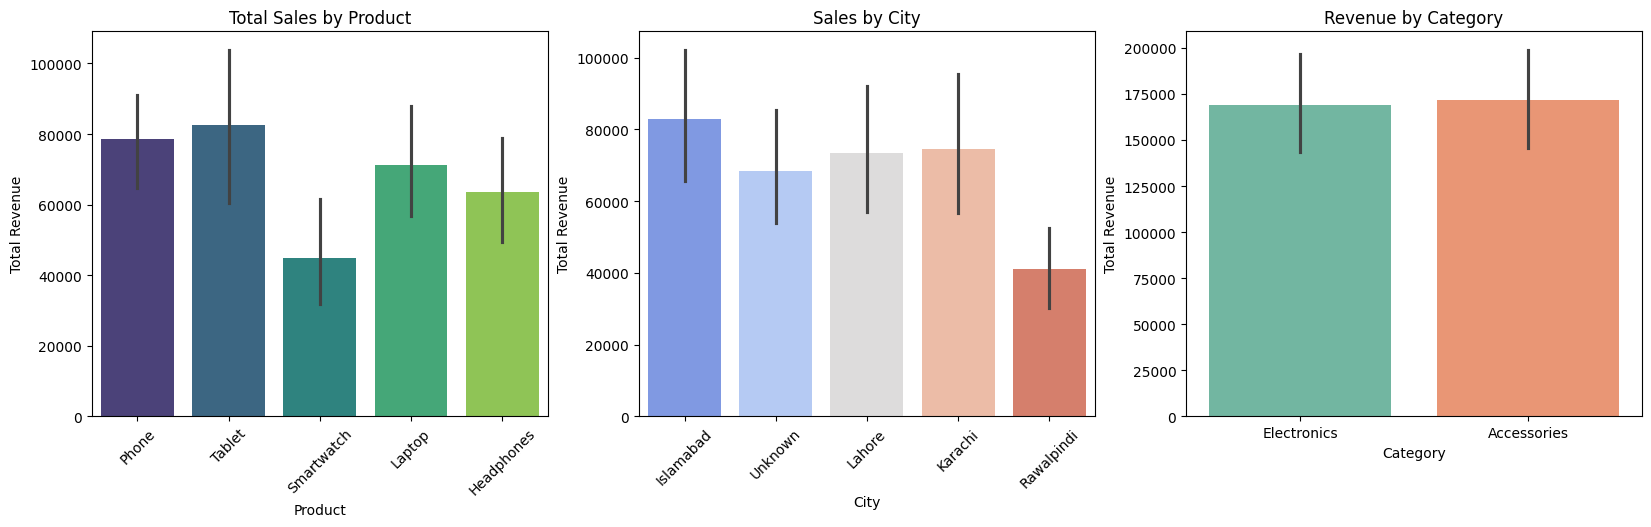

In [ ]:
plt.figure(figsize=(20, 5))
#Bar plot-Total Sales by Product
plt.subplot(1, 3, 1)
sns.barplot(
    x='Product',
    y='Revenue',
    data=df,
    estimator=sum,
    palette='viridis'
)

plt.title('Total Sales by Product')
plt.ylabel('Total Revenue')
plt.xlabel('Product')
plt.xticks(rotation=45)
#Bar Plot – Sales by City
plt.subplot(1, 3, 2)
sns.barplot(
    x='City',
    y='Revenue',
    data=df,
    estimator=sum,
    palette='coolwarm'
)

plt.title('Sales by City')
plt.ylabel('Total Revenue')
plt.xlabel('City')
plt.xticks(rotation=45)
#Bar Plot – Category Revenue
plt.subplot(1, 3, 3)
sns.barplot(
    x='Category',
    y='Revenue',
    data=df,
    estimator=sum,
    palette='Set2'
)

plt.title('Revenue by Category')
plt.ylabel('Total Revenue')
plt.xlabel('Category')
#Bonus: Line Plot with Styling

sns.lineplot(
    x='Order_Date',
    y='Revenue',
    data=df,
    estimator=sum
)

plt.title('Revenue Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()


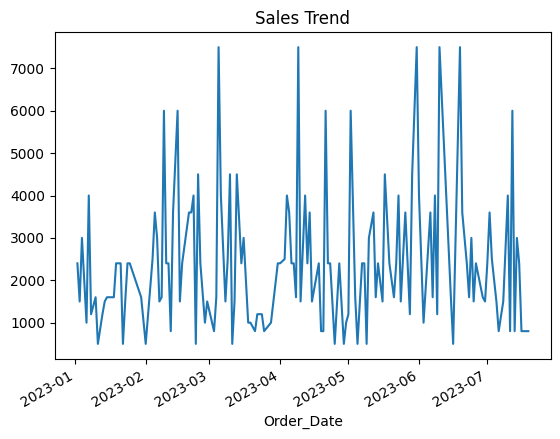

In [ ]:
#Line Chart
sales_trend.plot()
plt.title("Sales Trend")
plt.show()

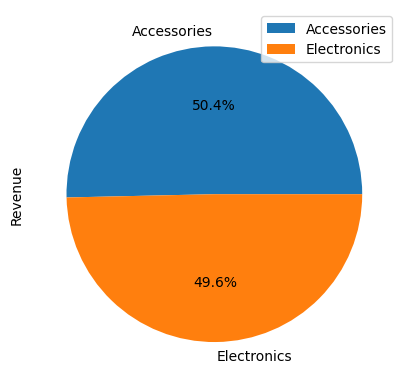

In [ ]:
#Pie Chart
category_revenue.plot(kind='pie', autopct='%1.1f%%')
plt.legend()
plt.show()

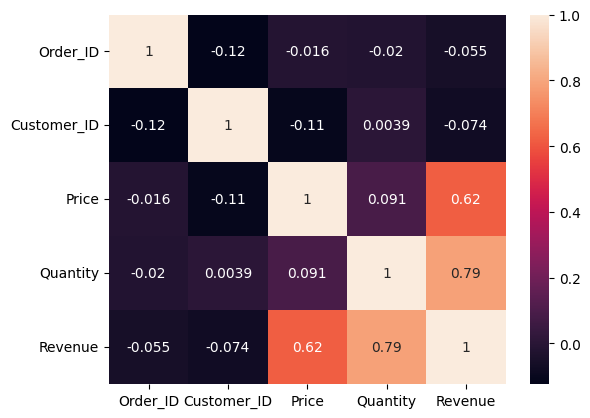

In [ ]:
#Heatmap
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()